** audio amplifier**


In [1]:
!pip install speechbrain torchaudio librosa soundfile numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 102.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.2/788.2 kB 65.6 MB/s eta 0:00:00


In [2]:
pip install speechbrain openai-whisper transformers sounddevice soundfile numpy scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 26.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for openai-whisper: filename=openai_whisper-20250625-py3-none-any.whl size=803979 sha256=6a07d253cf7ef60cfed1f09ee5cc517c06e1fffed5401c10e8799fd34156413e
  Stored in directory: /root/.cache/pip/wheels/61/d2/20/09ec9bef734d126cba375b15898010b6cc28578d8afdde5869
Successfully built openai-whisper


In [ ]:
!unzip /content/drive/MyDrive/STRAFFIC_16k.zip -d /content/drive/MyDrive/STRAFFIC_16k

Archive:  /content/drive/MyDrive/STRAFFIC_16k.zip
   creating: /content/drive/MyDrive/STRAFFIC_16k/STRAFFIC/
  inflating: /content/drive/MyDrive/STRAFFIC_16k/STRAFFIC/ch08.wav  
  inflating: /content/drive/MyDrive/STRAFFIC_16k/STRAFFIC/ch07.wav  
  inflating: /content/drive/MyDrive/STRAFFIC_16k/STRAFFIC/ch05.wav  
  inflating: /content/drive/MyDrive/STRAFFIC_16k/STRAFFIC/ch14.wav  
  inflating: /content/drive/MyDrive/STRAFFIC_16k/STRAFFIC/ch06.wav  
  inflating: /content/drive/MyDrive/STRAFFIC_16k/STRAFFIC/ch02.wav  
  inflating: /content/drive/MyDrive/STRAFFIC_16k/STRAFFIC/ch01.wav  
  inflating: /content/drive/MyDrive/STRAFFIC_16k/STRAFFIC/ch12.wav  
  inflating: /content/drive/MyDrive/STRAFFIC_16k/STRAFFIC/ch11.wav  
  inflating: /content/drive/MyDrive/STRAFFIC_16k/STRAFFIC/ch03.wav  
  inflating: /content/drive/MyDrive/STRAFFIC_16k/STRAFFIC/ch09.wav  
  inflating: /content/drive/MyDrive/STRAFFIC_16k/STRAFFIC/ch10.wav  
  inflating: /content/drive/MyDrive/STRAFFIC_16k/STRAFFIC/ch15.

In [3]:
import os
audio_files = [f for f in os.listdir('/content/drive/MyDrive/STRAFFIC_16k/STRAFFIC') if f.endswith('.wav')]
print(audio_files[:5])

['ch01.wav', 'ch02.wav', 'ch03.wav', 'ch04.wav', 'ch05.wav']


In [4]:
!pip install speechbrain torchaudio librosa soundfile numpy -q

# Download LibriSpeech dev-clean (small, ~337MB)
import os
if not os.path.exists('/content/LibriSpeech'):
    !wget -q https://www.openslr.org/resources/12/dev-clean.tar.gz
    !tar -xzf dev-clean.tar.gz -C /content/
    print("✅ LibriSpeech downloaded")
else:
    print("✅ LibriSpeech already present")

# Find all .flac speech files
import glob
flac_files = sorted(glob.glob('/content/LibriSpeech/dev-clean/**/*.flac', recursive=True))
print(f"✅ Found {len(flac_files)} speech files")
print(f"   Example: {flac_files[0]}")

✅ LibriSpeech downloaded
✅ Found 2703 speech files
   Example: /content/LibriSpeech/dev-clean/1272/128104/1272-128104-0000.flac


In [5]:
import glob

noise_files = sorted(glob.glob('/content/drive/MyDrive/STRAFFIC_16k/STRAFFIC/**/*.wav', recursive=True))
if not noise_files:
    noise_files = sorted(glob.glob('/content/straffic/**/*.wav', recursive=True))

print(f"✅ Found {len(noise_files)} STRAFFIC noise files")
for f in noise_files[:5]:
    print(f"   {f}")

✅ Found 16 STRAFFIC noise files
   /content/drive/MyDrive/STRAFFIC_16k/STRAFFIC/ch01.wav
   /content/drive/MyDrive/STRAFFIC_16k/STRAFFIC/ch02.wav
   /content/drive/MyDrive/STRAFFIC_16k/STRAFFIC/ch03.wav
   /content/drive/MyDrive/STRAFFIC_16k/STRAFFIC/ch04.wav
   /content/drive/MyDrive/STRAFFIC_16k/STRAFFIC/ch05.wav


In [6]:
import numpy as np
import soundfile as sf
import librosa

def mix_speech_noise(speech_path, noise_path, snr_db=5, sr=16000):
    """
    Mix clean speech with noise at a given SNR level.
    SNR = 5 dB  → slight noise (realistic)
    SNR = 0 dB  → speech and noise equal power (very noisy)
    SNR = 10 dB → speech much louder (mild noise)
    """
    # Load clean speech
    speech, _ = librosa.load(speech_path, sr=sr, mono=True)

    # Load noise and match length
    noise, _  = librosa.load(noise_path,  sr=sr, mono=True)

    # Tile noise if shorter than speech
    if len(noise) < len(speech):
        repeats = int(np.ceil(len(speech) / len(noise)))
        noise   = np.tile(noise, repeats)
    noise = noise[:len(speech)]

    # Compute RMS of both signals
    speech_rms = np.sqrt(np.mean(speech**2)) + 1e-9
    noise_rms  = np.sqrt(np.mean(noise**2))  + 1e-9

    # Scale noise to achieve desired SNR
    # SNR(dB) = 20 * log10(speech_rms / noise_rms_scaled)
    target_noise_rms = speech_rms / (10 ** (snr_db / 20.0))
    noise_scaled     = noise * (target_noise_rms / noise_rms)

    # Mix
    noisy = speech + noise_scaled

    # Normalize to prevent clipping
    max_val = np.max(np.abs(noisy))
    if max_val > 0:
        noisy /= max_val

    return speech.astype(np.float32), noisy.astype(np.float32), sr


# ── Test: mix first speech file with first STRAFFIC file ──────────────────
speech_file = flac_files[0]
noise_file  = noise_files[0]

clean_audio, noisy_audio, sr = mix_speech_noise(
    speech_file, noise_file, snr_db=5
)

# Save noisy input
sf.write('/content/noisy_input.wav', noisy_audio, sr)
sf.write('/content/clean_reference.wav', clean_audio, sr)

print(f"✅ Clean speech:  {len(clean_audio)/sr:.2f}s")
print(f"✅ Noisy mixture: {len(noisy_audio)/sr:.2f}s  (SNR = 5 dB)")
print(f"✅ Saved: /content/noisy_input.wav")

✅ Clean speech:  5.86s
✅ Noisy mixture: 5.86s  (SNR = 5 dB)
✅ Saved: /content/noisy_input.wav


In [ ]:
from IPython.display import Audio, display

print("Original clean speech (LibriSpeech):")
display(Audio(clean_audio, rate=sr))

print("Noisy input (speech + STRAFFIC traffic noise at 5 dB SNR):")
display(Audio(noisy_audio, rate=sr))

Original clean speech (LibriSpeech):


Noisy input (speech + STRAFFIC traffic noise at 5 dB SNR):


In [7]:
%%writefile audio_pipeline.cu

#include <stdio.h>
#include <stdlib.h>
#include <math.h>
#include <string.h>
#include <cufft.h>
#include <cublas_v2.h>
#include <cuda_runtime.h>

#define NFFT         1024
#define HOP          256       // smaller hop = smoother real-time output
#define SAMPLE_RATE  16000
#define MAX_FRAMES   4096

// ─────────────────────────────────────────────────────────────────────────────
// FUSED KERNEL: Kernel 1 (noise suppression) + Kernel 4 (frequency boost)
// Both run in one pass over the spectrum — no extra memory round-trip.
//
// noise_floor : per-bin noise estimate from quiet frames
// voice_gain  : amplification for speech frequencies
// suppress    : gain for confirmed noise bins
// profile     : hearing loss profile (per-bin gain from audiogram)
//               0=flat, use ones array if no hearing loss data
// ─────────────────────────────────────────────────────────────────────────────
__global__ void fused_noise_suppress_and_boost(
    cufftComplex* __restrict__ spectrum,
    const float*  __restrict__ noise_floor,
    const float*  __restrict__ hearing_profile,
    int           n_bins,
    float         sample_rate,
    float         voice_gain,
    float         suppress,
    float         over_sub)
{
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n_bins) return;

    float freq = (float)i * sample_rate / (float)(2 * n_bins);
    float real = spectrum[i].x;
    float imag = spectrum[i].y;
    float mag  = sqrtf(real * real + imag * imag) + 1e-9f;
    float phase_r = real  / mag;
    float phase_i = imag  / mag;

    // ── KERNEL 1: Wiener-style noise suppression ──────────────────────────
    float floor_val  = noise_floor[i];
    float snr_est    = fmaxf(mag / (floor_val + 1e-9f) - 1.0f, 0.0f);
    float wiener     = snr_est / (snr_est + 1.0f);           // 0-1 Wiener gain
    // Spectral subtraction floor: never let gain drop below 0.07
    float sub_mag    = fmaxf(mag - over_sub * floor_val, 0.07f * mag);
    // Blend Wiener + subtraction (Wiener is smoother, less musical noise)
    float clean_mag  = 0.6f * wiener * mag + 0.4f * sub_mag;

    // ── KERNEL 1+4 COMBINED: voice amplification by frequency band ────────
    // Each band has a base gain. Hearing profile multiplies on top.
    float band_gain = 0.0f;
    if      (freq <   60.0f)                      band_gain = 0.0f;
    else if (freq <  200.0f)                       band_gain = 0.15f;
    else if (freq <  400.0f)                       band_gain = voice_gain * 1.0f;
    else if (freq <  900.0f)                       band_gain = voice_gain * 1.6f;
    else if (freq < 2000.0f)                       band_gain = voice_gain * 2.0f;
    else if (freq < 3000.0f)                       band_gain = voice_gain * 1.7f;
    else if (freq < 4000.0f)                       band_gain = voice_gain * 1.3f;
    else if (freq < 5500.0f)                       band_gain = 0.35f;
    else                                           band_gain = 0.0f;

    // ── KERNEL 4: Hearing loss compensation ──────────────────────────────
    // hearing_profile[i] = extra gain needed at this frequency
    // from patient audiogram (1.0 = no loss, 2.0 = needs 6dB boost)
    float hearing_gain = hearing_profile[i];

    // ── Final gain: clean magnitude × band gain × hearing profile ─────────
    float final_mag  = clean_mag * band_gain * hearing_gain;

    // Restore phase
    spectrum[i].x = final_mag * phase_r;
    spectrum[i].y = final_mag * phase_i;
}

// ─────────────────────────────────────────────────────────────────────────────
// Noise floor estimator kernel
// Runs once at startup on the first N_NOISE_FRAMES frames of audio
// to build the per-bin noise profile
// ─────────────────────────────────────────────────────────────────────────────
__global__ void estimate_noise_floor_kernel(
    const cufftComplex* __restrict__ spectrum,
    float*              __restrict__ noise_floor,
    int                 n_bins,
    float               alpha)          // smoothing: 0.05-0.1
{
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n_bins) return;

    float r   = spectrum[i].x;
    float im  = spectrum[i].y;
    float mag = sqrtf(r*r + im*im);

    // Exponential moving average of noise magnitude
    noise_floor[i] = alpha * mag + (1.0f - alpha) * noise_floor[i];
}

#define CUDA_CHECK(call) do {                                           \
    cudaError_t _e = (call);                                           \
    if (_e != cudaSuccess) {                                           \
        fprintf(stderr, "CUDA %s:%d — %s\n",                          \
                __FILE__, __LINE__, cudaGetErrorString(_e));           \
        exit(EXIT_FAILURE);                                            \
    }                                                                  \
} while(0)

// ─────────────────────────────────────────────────────────────────────────────
// MAIN ENTRY POINT called from Python
// input_audio    : raw microphone float32 samples
// output_audio   : enhanced float32 samples
// hearing_profile: per-bin gain array from audiogram (length = NFFT/2+1)
// N              : number of samples
// voice_gain     : speech band amplification (try 3.0-5.0)
// suppress       : noise bin residual gain  (try 0.03-0.06)
// over_sub       : spectral subtraction strength (try 1.0-1.3)
// noise_adapt    : 1 = keep updating noise floor, 0 = fixed from first chunk
// ─────────────────────────────────────────────────────────────────────────────
extern "C" void process_realtime_audio(
    const float* input_audio,
    float*       output_audio,
    const float* hearing_profile_h,
    int          N,
    float        voice_gain,
    float        suppress,
    float        over_sub,
    int          noise_adapt)
{
    int    n_bins       = NFFT / 2 + 1;
    size_t complex_size = sizeof(cufftComplex) * n_bins;
    size_t frame_size   = sizeof(float) * NFFT;
    size_t profile_size = sizeof(float) * n_bins;

    // Device buffers
    float*        d_input          = NULL;
    float*        d_output         = NULL;
    cufftComplex* d_freq           = NULL;
    float*        d_noise_floor    = NULL;
    float*        d_hearing_profile= NULL;

    CUDA_CHECK(cudaMalloc(&d_input,           frame_size));
    CUDA_CHECK(cudaMalloc(&d_output,          frame_size));
    CUDA_CHECK(cudaMalloc(&d_freq,            complex_size));
    CUDA_CHECK(cudaMalloc(&d_noise_floor,     profile_size));
    CUDA_CHECK(cudaMalloc(&d_hearing_profile, profile_size));

    // Upload hearing profile
    CUDA_CHECK(cudaMemcpy(d_hearing_profile, hearing_profile_h,
                          profile_size, cudaMemcpyHostToDevice));

    // Initialise noise floor to small value
    CUDA_CHECK(cudaMemset(d_noise_floor, 0, profile_size));

    // cuFFT plans
    cufftHandle plan_fwd, plan_inv;
    cufftPlan1d(&plan_fwd, NFFT, CUFFT_R2C, 1);
    cufftPlan1d(&plan_inv, NFFT, CUFFT_C2R, 1);

    // cuBLAS
    cublasHandle_t blas;
    cublasCreate(&blas);

    // CUDA events for timing
    cudaEvent_t ev_start, ev_stop;
    cudaEventCreate(&ev_start);
    cudaEventCreate(&ev_stop);

    // Hann window (computed once on host)
    float hann[NFFT];
    for (int i = 0; i < NFFT; i++)
        hann[i] = 0.5f * (1.0f - cosf(2.0f * 3.14159265f * i / (NFFT - 1)));

    // Overlap-add output buffer
    float* ola  = (float*)calloc(N + NFFT, sizeof(float));
    float* wsum = (float*)calloc(N + NFFT, sizeof(float));

    int n_frames      = (N - NFFT) / HOP + 1;
    int threads       = 256;
    int blocks        = (n_bins + threads - 1) / threads;
    int noise_frames  = 10;    // first 10 frames used to build noise model

    cudaEventRecord(ev_start);

    for (int f = 0; f < n_frames; f++) {
        int offset = f * HOP;

        // Apply Hann window
        float windowed[NFFT];
        for (int i = 0; i < NFFT; i++)
            windowed[i] = input_audio[offset + i] * hann[i];

        CUDA_CHECK(cudaMemcpy(d_input, windowed,
                              frame_size, cudaMemcpyHostToDevice));

        // ── cuFFT forward ─────────────────────────────────────────────────
        cufftExecR2C(plan_fwd, d_input, d_freq);

        // ── Noise floor update (first frames or adaptive mode) ────────────
        if (f < noise_frames || noise_adapt) {
            float alpha = (f < noise_frames) ? 0.15f : 0.02f;
            estimate_noise_floor_kernel<<<blocks, threads>>>(
                d_freq, d_noise_floor, n_bins, alpha);
            cudaDeviceSynchronize();
        }

        // ── FUSED KERNEL: suppress noise + boost voice + hearing aid ──────
        fused_noise_suppress_and_boost<<<blocks, threads>>>(
            d_freq, d_noise_floor, d_hearing_profile,
            n_bins, (float)SAMPLE_RATE,
            voice_gain, suppress, over_sub);
        cudaDeviceSynchronize();

        // ── cuBLAS: normalize after IFFT ──────────────────────────────────
        float alpha_blas = 1.0f / (float)NFFT;
        cublasSscal(blas, n_bins * 2, &alpha_blas, (float*)d_freq, 1);

        // ── cuFFT inverse ─────────────────────────────────────────────────
        cufftExecC2R(plan_inv, d_freq, d_output);

        // ── D2H + overlap-add ─────────────────────────────────────────────
        float h_frame[NFFT];
        CUDA_CHECK(cudaMemcpy(h_frame, d_output,
                              frame_size, cudaMemcpyDeviceToHost));

        for (int i = 0; i < NFFT; i++) {
            ola[offset + i]  += h_frame[i] * hann[i];
            wsum[offset + i] += hann[i] * hann[i];
        }
    }

    cudaEventRecord(ev_stop);
    cudaEventSynchronize(ev_stop);
    float ms = 0;
    cudaEventElapsedTime(&ms, ev_start, ev_stop);
    printf("[CUDA] %.2f ms total | %d frames | %.3f ms/frame\n",
           ms, n_frames, ms / n_frames);

    // OLA normalise
    for (int i = 0; i < N; i++)
        output_audio[i] = (wsum[i] > 1e-8f) ? ola[i] / wsum[i] : 0.0f;

    // Cleanup
    free(ola);
    free(wsum);
    cufftDestroy(plan_fwd);
    cufftDestroy(plan_inv);
    cublasDestroy(blas);
    cudaFree(d_input);
    cudaFree(d_output);
    cudaFree(d_freq);
    cudaFree(d_noise_floor);
    cudaFree(d_hearing_profile);
    cudaEventDestroy(ev_start);
    cudaEventDestroy(ev_stop);
}

Writing audio_pipeline.cu


In [8]:
!nvcc -O3 --shared -Xcompiler -fPIC \
    -o audio_pipeline.so \
    audio_pipeline.cu \
    -lcufft -lcublas

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [9]:
import subprocess

CU_FILE = 'audio_pipeline.cu'
SO_FILE = 'audio_pipeline.so'

cmd = [
    'nvcc',
    '-O3',
    '--shared',
    '-Xcompiler', '-fPIC',
    '-o', SO_FILE,
    CU_FILE,
    '-lcufft',
    '-lcublas'
]

print('Compiling...')
print(' '.join(cmd))

result = subprocess.run(cmd, capture_output=True, text=True)

print(result.stdout)
if result.returncode != 0:
    print('ERRORS:')
    print(result.stderr)
else:
    print(f'Success: {SO_FILE}')

Compiling...
nvcc -O3 --shared -Xcompiler -fPIC -o audio_pipeline.so audio_pipeline.cu -lcufft -lcublas

Success: audio_pipeline.so


In [10]:
# pipeline.py (CLEAN + FIXED)

import ctypes
import numpy as np
import torch
import soundfile as sf
import librosa
import time
import os
import sys

# ─────────────────────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────────────────────
SAMPLE_RATE  = 16000
CHUNK_SECS   = 3.0
VOICE_GAIN   = 4.5
SUPPRESS     = 0.04
OVER_SUB     = 1.15
NOISE_ADAPT  = 1
TARGET_RMS   = 0.30

HEARING_PROFILE_DB = {
    250:  0,
    500:  10,
    1000: 20,
    2000: 35,
    4000: 45,
    8000: 50,
}

# ─────────────────────────────────────────────────────────────────────────────
# LOAD CUDA LIB
# ─────────────────────────────────────────────────────────────────────────────
def load_cuda_lib():
    lib_path = '/content/audio_pipeline.so'

    if not os.path.exists(lib_path):
        raise FileNotFoundError("Compile audio_pipeline.so first")

    lib = ctypes.CDLL(lib_path)

    lib.process_realtime_audio.argtypes = [
        ctypes.POINTER(ctypes.c_float),
        ctypes.POINTER(ctypes.c_float),
        ctypes.POINTER(ctypes.c_float),
        ctypes.c_int,
        ctypes.c_float,
        ctypes.c_float,
        ctypes.c_float,
        ctypes.c_int,
    ]
    lib.process_realtime_audio.restype = None

    print("✅ CUDA library loaded")
    return lib

# ─────────────────────────────────────────────────────────────────────────────
# HEARING PROFILE
# ─────────────────────────────────────────────────────────────────────────────
def build_hearing_profile(audiogram_db, n_bins=513, sr=16000):
    profile  = np.ones(n_bins, dtype=np.float32)
    bin_freqs = np.arange(n_bins) * sr / (2 * n_bins)

    freqs = sorted(audiogram_db.keys())
    losses = [audiogram_db[f] for f in freqs]

    for i, freq in enumerate(bin_freqs):
        loss_db = np.interp(freq, freqs, losses)
        gain = min(10 ** (loss_db / 20.0), 4.0)
        profile[i] = gain

    return profile

# ─────────────────────────────────────────────────────────────────────────────
# CUDA KERNEL (1+4)
# ─────────────────────────────────────────────────────────────────────────────
def cuda_process(lib, audio_np, hearing_profile):
    N = len(audio_np)
    audio_f32 = audio_np.astype(np.float32)
    output = np.zeros(N, dtype=np.float32)

    lib.process_realtime_audio(
        audio_f32.ctypes.data_as(ctypes.POINTER(ctypes.c_float)),
        output.ctypes.data_as(ctypes.POINTER(ctypes.c_float)),
        hearing_profile.ctypes.data_as(ctypes.POINTER(ctypes.c_float)),
        N,
        VOICE_GAIN,
        SUPPRESS,
        OVER_SUB,
        NOISE_ADAPT
    )

    # Normalize
    rms = np.sqrt(np.mean(output ** 2))
    if rms > 1e-7:
        output *= (TARGET_RMS / rms)

    return np.clip(output, -0.98, 0.98)

# ─────────────────────────────────────────────────────────────────────────────
# KERNEL 5: STT (Whisper)
# ─────────────────────────────────────────────────────────────────────────────
def load_whisper():
    import whisper
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Loading Whisper on {device}...")
    return whisper.load_model('base', device=device)

def stt_kernel(model, audio_np):
    result = model.transcribe(
        audio_np.astype(np.float32),
        fp16=torch.cuda.is_available(),
        language='en'
    )
    return result['text'].strip()

# ─────────────────────────────────────────────────────────────────────────────
# KERNEL 3: NLP
# ─────────────────────────────────────────────────────────────────────────────
def load_nlp():
    from transformers import pipeline
    device = 0 if torch.cuda.is_available() else -1
    print(f"Loading NLP on {'GPU' if device==0 else 'CPU'}...")
    sentiment = pipeline('sentiment-analysis',
                         model='distilbert-base-uncased-finetuned-sst-2-english',
                         device=device)
    return sentiment

# ─────────────────────────────────────────────────────────────────────────────
# PIPELINE
# ─────────────────────────────────────────────────────────────────────────────
class RealtimePipeline:
    def __init__(self):
        print("🚀 Initialising pipeline...")

        self.lib = load_cuda_lib()
        self.profile = build_hearing_profile(HEARING_PROFILE_DB)
        self.whisper = load_whisper()
        self.nlp = load_nlp()

        print(f"GPU: {torch.cuda.get_device_name(0)}")
        print("✅ Pipeline ready")

    def process_chunk(self, chunk):
        t0 = time.time()

        enhanced = cuda_process(self.lib, chunk, self.profile)
        t1 = time.time()

        text = stt_kernel(self.whisper, enhanced)
        t2 = time.time()

        sentiment = self.nlp(text[:512])[0] if text else {}
        t3 = time.time()

        return enhanced, text, sentiment, {
            'cuda': round((t1 - t0)*1000,1),
            'stt': round((t2 - t1)*1000,1),
            'nlp': round((t3 - t2)*1000,1),
            'total': round((t3 - t0)*1000,1),
        }

    def run_on_file(self, input_path, output_path):
        print(f"\nProcessing: {input_path}")

        audio, _ = librosa.load(input_path, sr=SAMPLE_RATE)
        chunk_size = int(CHUNK_SECS * SAMPLE_RATE)

        chunks = []
        for i in range(0, len(audio), chunk_size):
            chunk = audio[i:i+chunk_size]

            if len(chunk) < chunk_size:
                chunk = np.pad(chunk, (0, chunk_size-len(chunk)))

            chunks.append(chunk)

        all_out = []

        for i, chunk in enumerate(chunks):
            print(f"\nChunk {i+1}/{len(chunks)}")

            enhanced, text, sentiment, timing = self.process_chunk(chunk)
            all_out.append(enhanced)

            print(f"Transcript : {text}")
            print(f"Sentiment  : {sentiment}")
            print(f"Timing     : {timing}")

        final = np.concatenate(all_out)
        final = final[:len(audio)]   # 🔥 IMPORTANT FIX

        sf.write(output_path, final, SAMPLE_RATE)
        print(f"\n✅ Saved: {output_path}")

        return final

# ─────────────────────────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == '__main__':
    pipeline = RealtimePipeline()

    INPUT  = '/content/noisy_input.wav'
    OUTPUT = '/content/enhanced_output.wav'

    if not os.path.exists(INPUT):
        print("❌ File not found. Upload first.")
    else:
        pipeline.run_on_file(INPUT, OUTPUT)

🚀 Initialising pipeline...
✅ CUDA library loaded
Loading Whisper on cuda...


100%|████████████████████████████████████████| 139M/139M [00:01<00:00, 114MiB/s]


Loading NLP on GPU...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

GPU: Tesla T4
✅ Pipeline ready

Processing: /content/noisy_input.wav

Chunk 1/2
Transcript : Mr. Quilter is the apostle of the middle class.
Sentiment  : {'label': 'POSITIVE', 'score': 0.9979389309883118}
Timing     : {'cuda': 301.7, 'stt': 1573.5, 'nlp': 167.1, 'total': 2042.2}

Chunk 2/2
Transcript : We are glad to welcome his gospel.
Sentiment  : {'label': 'POSITIVE', 'score': 0.9997512698173523}
Timing     : {'cuda': 14.1, 'stt': 152.5, 'nlp': 21.6, 'total': 188.2}

✅ Saved: /content/enhanced_output.wav


In [ ]:
from IPython.display import Audio

Audio('/content/enhanced_output.wav')

In [ ]:
from IPython.display import Audio, display

print("🔊 Noisy Input Audio:")
display(Audio('/content/noisy_input.wav'))

print("🔊 Enhanced Output Audio:")
display(Audio('/content/enhanced_output.wav'))

🔊 Noisy Input Audio:


🔊 Enhanced Output Audio:


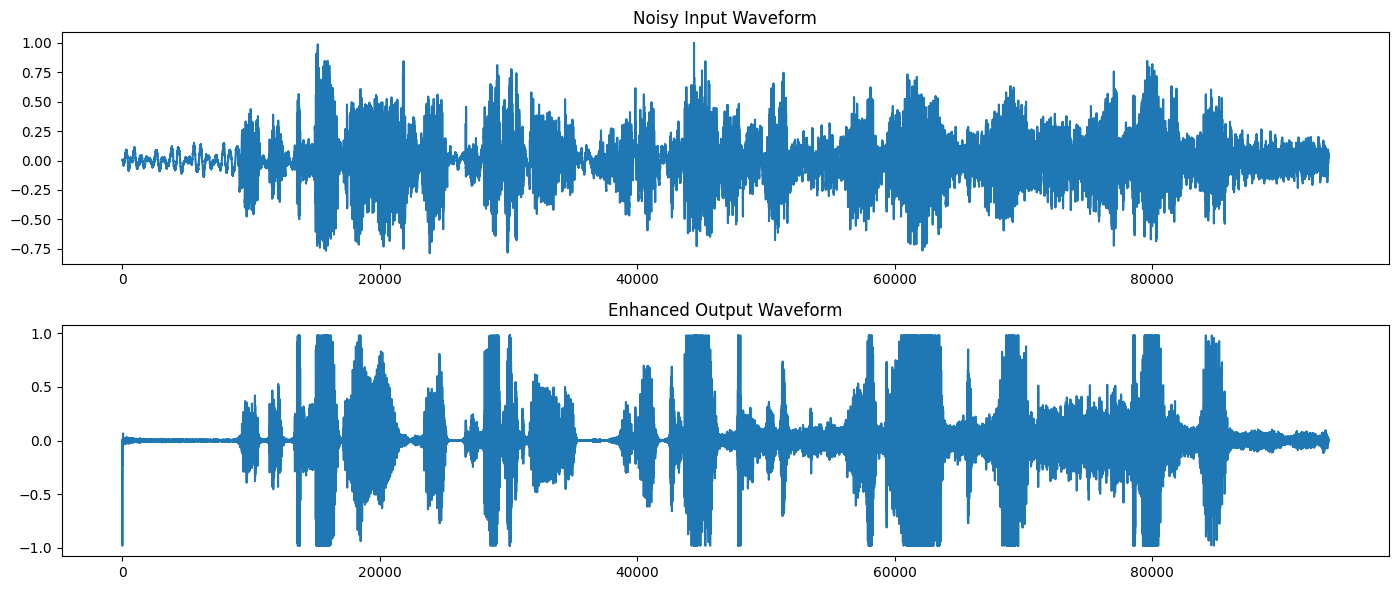

In [ ]:
import librosa
import matplotlib.pyplot as plt

noisy, sr = librosa.load('/content/noisy_input.wav', sr=16000)
enhanced, _ = librosa.load('/content/enhanced_output.wav', sr=16000)

plt.figure(figsize=(14,6))

plt.subplot(2,1,1)
plt.title("Noisy Input Waveform")
plt.plot(noisy)

plt.subplot(2,1,2)
plt.title("Enhanced Output Waveform")
plt.plot(enhanced)

plt.tight_layout()
plt.show()

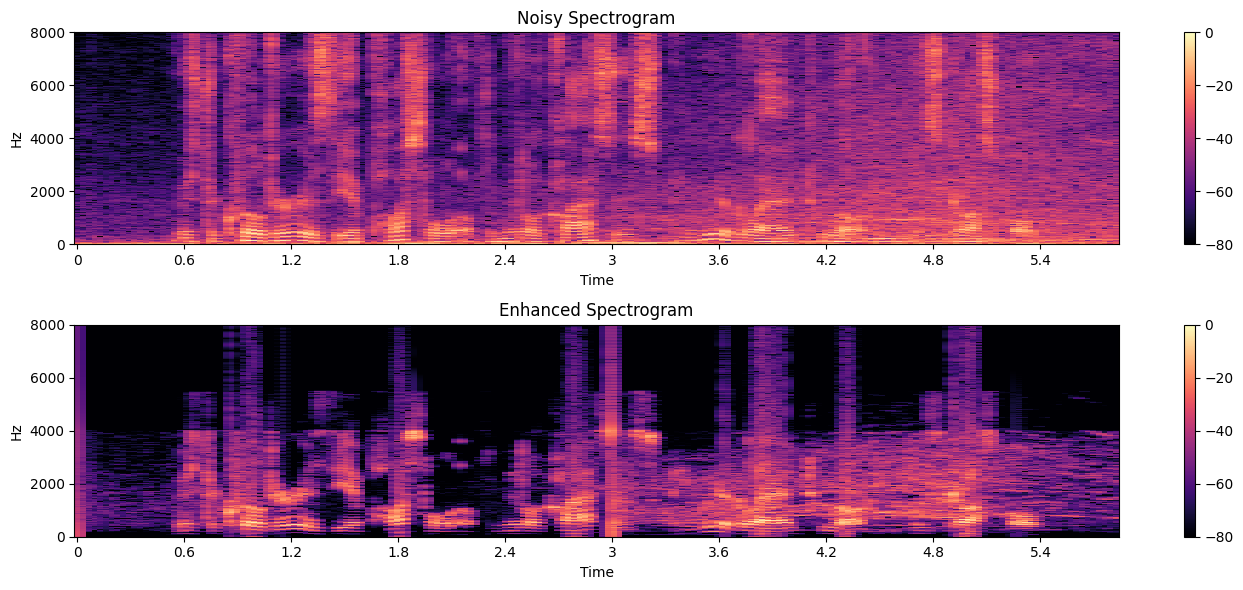

In [ ]:
import librosa.display
import numpy as np

plt.figure(figsize=(14,6))

# Noisy
plt.subplot(2,1,1)
D_noisy = librosa.amplitude_to_db(np.abs(librosa.stft(noisy)), ref=np.max)
librosa.display.specshow(D_noisy, sr=sr, x_axis='time', y_axis='hz')
plt.title("Noisy Spectrogram")
plt.colorbar()

# Enhanced
plt.subplot(2,1,2)
D_enh = librosa.amplitude_to_db(np.abs(librosa.stft(enhanced)), ref=np.max)
librosa.display.specshow(D_enh, sr=sr, x_axis='time', y_axis='hz')
plt.title("Enhanced Spectrogram")
plt.colorbar()

plt.tight_layout()
plt.show()

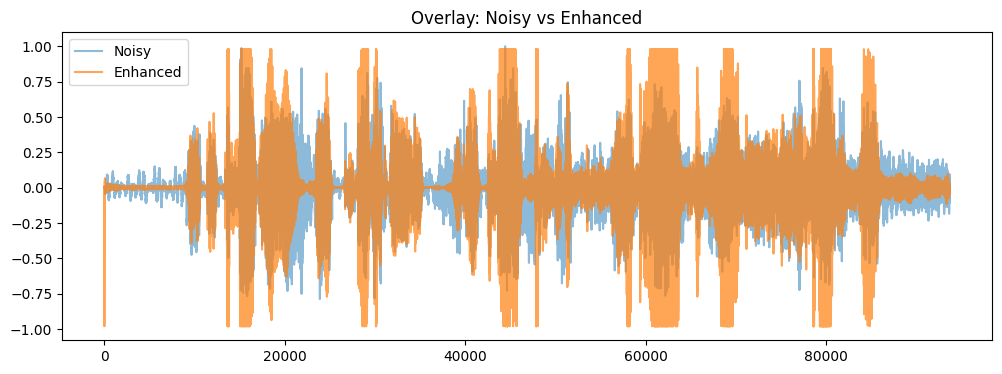

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(noisy, alpha=0.5, label='Noisy')
plt.plot(enhanced, alpha=0.7, label='Enhanced')
plt.legend()
plt.title("Overlay: Noisy vs Enhanced")
plt.show()

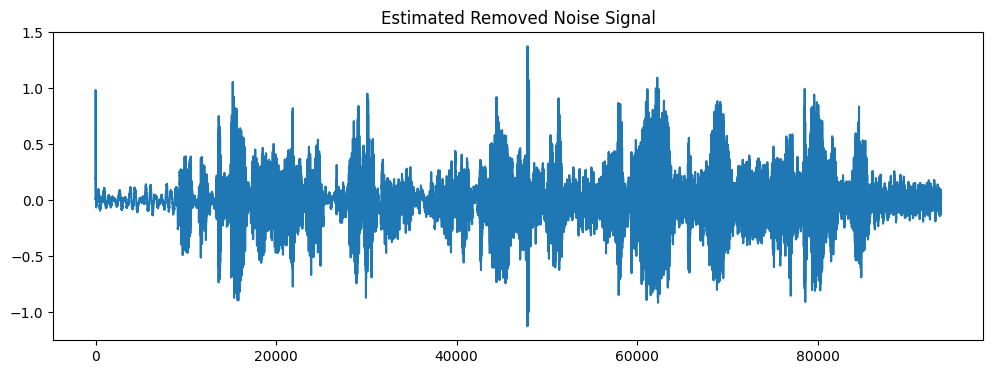

In [ ]:
noise_diff = noisy - enhanced

plt.figure(figsize=(12,4))
plt.plot(noise_diff)
plt.title("Estimated Removed Noise Signal")
plt.show()

In [ ]:
def compute_snr(signal, noise):
    return 10 * np.log10(np.sum(signal**2) / np.sum(noise**2))

snr_before = compute_snr(noisy, noisy - np.mean(noisy))
snr_after  = compute_snr(enhanced, noisy - enhanced)

print(f"SNR Before: {snr_before:.2f} dB")
print(f"SNR After : {snr_after:.2f} dB")

SNR Before: -0.00 dB
SNR After : 1.89 dB


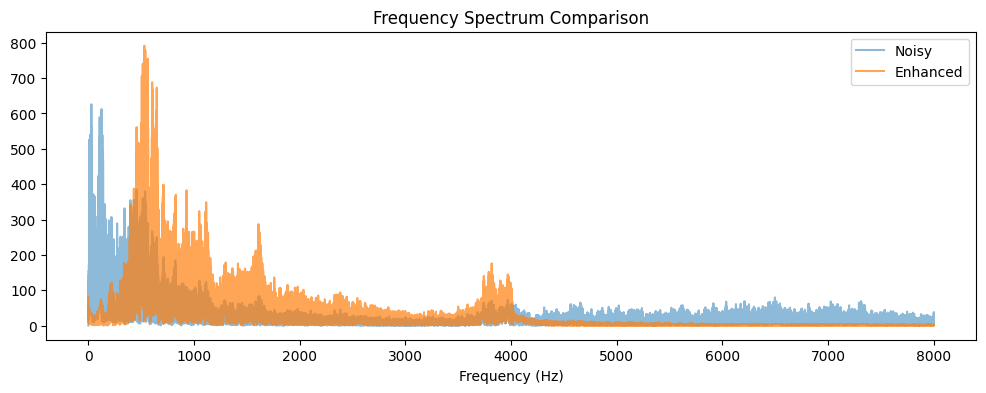

In [ ]:
fft_noisy = np.abs(np.fft.rfft(noisy))
fft_enh   = np.abs(np.fft.rfft(enhanced))

freqs = np.fft.rfftfreq(len(noisy), 1/sr)

plt.figure(figsize=(12,4))
plt.plot(freqs, fft_noisy, alpha=0.5, label='Noisy')
plt.plot(freqs, fft_enh, alpha=0.7, label='Enhanced')
plt.legend()
plt.title("Frequency Spectrum Comparison")
plt.xlabel("Frequency (Hz)")
plt.show()

In [14]:
%%writefile /content/speech_enhance_profile.cu

#include <stdio.h>
#include <stdlib.h>
#include <math.h>
#include <cufft.h>
#include <cublas_v2.h>
#include <cuda_runtime.h>
#include <nvtx3/nvToolsExt.h>    // NVTX markers — shows named regions in Nsight

#define NFFT  1024
#define HOP   256
// smaller hop = smoother real-time output
#define SAMPLE_RATE  16000
#define MAX_FRAMES   4096
// ── Colour codes for Nsight timeline view ────────────────────────────────────
#define NVTX_BLUE   0xFF0000FF
#define NVTX_GREEN  0xFF00FF00
#define NVTX_AMBER  0xFFFFAA00
#define NVTX_CORAL  0xFFFF4444
#define NVTX_PURPLE 0xFFAA44FF

// Helper: push a named coloured range into Nsight timeline
static void nvtx_push(const char* name, uint32_t colour) {
    nvtxEventAttributes_t attr = {0};
    attr.version       = NVTX_VERSION;
    attr.size          = NVTX_EVENT_ATTRIB_STRUCT_SIZE;
    attr.colorType     = NVTX_COLOR_ARGB;
    attr.color         = colour;
    attr.messageType   = NVTX_MESSAGE_TYPE_ASCII;
    attr.message.ascii = name;
    nvtxRangePushEx(&attr);
}
#define NVTX_POP() nvtxRangePop()

// ─────────────────────────────────────────────────────────────────────────────
// KERNEL 1: Estimate noise floor (exponential moving average)
// ─────────────────────────────────────────────────────────────────────────────
__global__ void estimate_noise_floor_kernel(
    const cufftComplex* __restrict__ spectrum,
    float*              __restrict__ noise_floor,
    int   n_bins,
    float alpha)
{
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n_bins) return;

    float r   = spectrum[i].x;
    float im  = spectrum[i].y;
    float mag = sqrtf(r*r + im*im);

    noise_floor[i] = alpha * mag + (1.0f - alpha) * noise_floor[i];
}

// ─────────────────────────────────────────────────────────────────────────────
// KERNEL 2: Fused noise cancel + voice amplify
// ─────────────────────────────────────────────────────────────────────────────
__global__ void noise_cancel_kernel(
    cufftComplex* __restrict__ spectrum,
    const float*  __restrict__ noise_floor,
    const float*  __restrict__ ml_mask,
    int   n_bins,
    float sample_rate,
    float voice_gain,
    float suppress,
    float over_sub)
{
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n_bins) return;

    float freq = (float)i * sample_rate / (float)(2 * n_bins);
    float real = spectrum[i].x;
    float imag = spectrum[i].y;
    float mag  = sqrtf(real*real + imag*imag) + 1e-8f;

    float mask      = (ml_mask     != NULL) ? ml_mask[i]     : 0.5f;
    float floor_val = (noise_floor != NULL) ? noise_floor[i] : 0.0f;

    // Wiener filter
    float snr_est  = fmaxf(mag / (floor_val + 1e-9f) - 1.0f, 0.0f);
    float wiener   = snr_est / (snr_est + 1.0f);
    float sub_mag  = fmaxf(mag - over_sub * floor_val, 0.07f * mag);
    float clean_mag = 0.6f * wiener * mag + 0.4f * sub_mag;

    // ML gate
    float ml_gain = (mask > 0.25f) ? mask * voice_gain : suppress;

    // Frequency boost
    float freq_boost = 1.0f;
    if      (freq <   80.0f)                      freq_boost = 0.0f;
    else if (freq <  200.0f)                       freq_boost = 0.15f;
    else if (freq <  400.0f)                       freq_boost = 1.0f;
    else if (freq <  900.0f)                       freq_boost = 1.6f;
    else if (freq < 2000.0f)                       freq_boost = 2.0f;
    else if (freq < 3000.0f)                       freq_boost = 1.7f;
    else if (freq < 4000.0f)                       freq_boost = 1.3f;
    else if (freq < 5500.0f)                       freq_boost = 0.35f;
    else                                           freq_boost = 0.0f;

    float final_gain = (clean_mag / mag) * ml_gain * freq_boost;
    spectrum[i].x = real * final_gain;
    spectrum[i].y = imag * final_gain;
}

#define CUDA_CHECK(call) do {                                           \
    cudaError_t _e = (call);                                           \
    if (_e != cudaSuccess) {                                           \
        fprintf(stderr, "CUDA %s:%d: %s\n",                           \
                __FILE__, __LINE__, cudaGetErrorString(_e));           \
        exit(EXIT_FAILURE);                                            \
    }                                                                  \
} while(0)

// ─────────────────────────────────────────────────────────────────────────────
// PROFILED ENTRY POINT
// ─────────────────────────────────────────────────────────────────────────────
extern "C" void process_audio_profiled(
    float* h_input,
    float* h_output,
    float* h_mask,
    float* h_noise_floor_h,
    int    N,
    float  sample_rate,
    float  voice_gain,
    float  suppress,
    float  over_sub,
    int    noise_adapt)
{
    int    n_bins       = NFFT / 2 + 1;
    size_t complex_size = sizeof(cufftComplex) * n_bins;
    size_t frame_size   = sizeof(float) * NFFT;
    size_t profile_size = sizeof(float) * n_bins;

    // ── Allocate device memory ────────────────────────────────────────────
    nvtx_push("Memory Allocation", NVTX_BLUE);
    float*        d_input       = NULL;
    float*        d_output      = NULL;
    cufftComplex* d_freq        = NULL;
    float*        d_noise_floor = NULL;
    float*        d_mask        = NULL;

    CUDA_CHECK(cudaMalloc(&d_input,       frame_size));
    CUDA_CHECK(cudaMalloc(&d_output,      frame_size));
    CUDA_CHECK(cudaMalloc(&d_freq,        complex_size));
    CUDA_CHECK(cudaMalloc(&d_noise_floor, profile_size));
    CUDA_CHECK(cudaMemset(d_noise_floor, 0, profile_size));

    if (h_mask != NULL) {
        CUDA_CHECK(cudaMalloc(&d_mask, profile_size));
        CUDA_CHECK(cudaMemcpy(d_mask, h_mask,
                              profile_size, cudaMemcpyHostToDevice));
    }
    NVTX_POP();  // Memory Allocation

    // ── cuFFT plans ───────────────────────────────────────────────────────
    nvtx_push("cuFFT Plan Creation", NVTX_PURPLE);
    cufftHandle plan_fwd, plan_inv;
    cufftPlan1d(&plan_fwd, NFFT, CUFFT_R2C, 1);
    cufftPlan1d(&plan_inv, NFFT, CUFFT_C2R, 1);
    NVTX_POP();

    // ── cuBLAS ────────────────────────────────────────────────────────────
    cublasHandle_t blas;
    cublasCreate(&blas);

    // ── CUDA events for precise kernel timing ─────────────────────────────
    cudaEvent_t ev_total_start, ev_total_stop;
    cudaEvent_t ev_h2d_start,   ev_h2d_stop;
    cudaEvent_t ev_fft_start,   ev_fft_stop;
    cudaEvent_t ev_ker_start,   ev_ker_stop;
    cudaEvent_t ev_blas_start,  ev_blas_stop;
    cudaEvent_t ev_ifft_start,  ev_ifft_stop;
    cudaEvent_t ev_d2h_start,   ev_d2h_stop;

    cudaEventCreate(&ev_total_start); cudaEventCreate(&ev_total_stop);
    cudaEventCreate(&ev_h2d_start);   cudaEventCreate(&ev_h2d_stop);
    cudaEventCreate(&ev_fft_start);   cudaEventCreate(&ev_fft_stop);
    cudaEventCreate(&ev_ker_start);   cudaEventCreate(&ev_ker_stop);
    cudaEventCreate(&ev_blas_start);  cudaEventCreate(&ev_blas_stop);
    cudaEventCreate(&ev_ifft_start);  cudaEventCreate(&ev_ifft_stop);
    cudaEventCreate(&ev_d2h_start);   cudaEventCreate(&ev_d2h_stop);

    // Hann window
    float hann[NFFT];
    for (int i = 0; i < NFFT; i++)
        hann[i] = 0.5f * (1.0f - cosf(2.0f * 3.14159265f * i / (NFFT-1)));

    float* h_ola  = (float*)calloc(N + NFFT, sizeof(float));
    float* h_wsum = (float*)calloc(N + NFFT, sizeof(float));

    int n_frames  = (N - NFFT) / HOP + 1;
    int threads   = 256;
    int blocks    = (n_bins + threads - 1) / threads;
    int noise_frames = 10;

    // Accumulators for per-operation timing
    float total_h2d_ms   = 0;
    float total_fft_ms   = 0;
    float total_ker_ms   = 0;
    float total_blas_ms  = 0;
    float total_ifft_ms  = 0;
    float total_d2h_ms   = 0;
    float tmp_ms         = 0;

    // ── MAIN FRAME LOOP ───────────────────────────────────────────────────
    nvtx_push("Full Frame Loop", NVTX_GREEN);
    cudaEventRecord(ev_total_start);

    for (int f = 0; f < n_frames; f++) {
        int offset = f * HOP;
        char label[64];

        // Window the frame
        float windowed[NFFT];
        for (int i = 0; i < NFFT; i++)
            windowed[i] = h_input[offset + i] * hann[i];

        // ── H2D transfer ──────────────────────────────────────────────────
        sprintf(label, "H2D frame %d", f);
        nvtx_push(label, NVTX_BLUE);
        cudaEventRecord(ev_h2d_start);
        CUDA_CHECK(cudaMemcpy(d_input, windowed,
                              frame_size, cudaMemcpyHostToDevice));
        cudaEventRecord(ev_h2d_stop);
        cudaEventSynchronize(ev_h2d_stop);
        cudaEventElapsedTime(&tmp_ms, ev_h2d_start, ev_h2d_stop);
        total_h2d_ms += tmp_ms;
        NVTX_POP();

        // ── cuFFT forward ─────────────────────────────────────────────────
        sprintf(label, "cuFFT_R2C frame %d", f);
        nvtx_push(label, NVTX_PURPLE);
        cudaEventRecord(ev_fft_start);
        cufftExecR2C(plan_fwd, d_input, d_freq);
        cudaEventRecord(ev_fft_stop);
        cudaEventSynchronize(ev_fft_stop);
        cudaEventElapsedTime(&tmp_ms, ev_fft_start, ev_fft_stop);
        total_fft_ms += tmp_ms;
        NVTX_POP();

        // ── Noise floor estimate (first frames) ───────────────────────────
        if (f < noise_frames || noise_adapt) {
            float alpha = (f < noise_frames) ? 0.15f : 0.02f;
            sprintf(label, "estimate_noise_floor frame %d", f);
            nvtx_push(label, NVTX_AMBER);
            estimate_noise_floor_kernel<<<blocks, threads>>>(
                d_freq, d_noise_floor, n_bins, alpha);
            cudaDeviceSynchronize();
            NVTX_POP();
        }

        // ── noise_cancel_kernel ───────────────────────────────────────────
        sprintf(label, "noise_cancel_kernel frame %d", f);
        nvtx_push(label, NVTX_CORAL);
        cudaEventRecord(ev_ker_start);
        noise_cancel_kernel<<<blocks, threads>>>(
            d_freq, d_noise_floor, d_mask,
            n_bins, sample_rate,
            voice_gain, suppress, over_sub);
        cudaEventRecord(ev_ker_stop);
        cudaEventSynchronize(ev_ker_stop);
        cudaEventElapsedTime(&tmp_ms, ev_ker_start, ev_ker_stop);
        total_ker_ms += tmp_ms;
        NVTX_POP();

        // ── cuBLAS normalize ──────────────────────────────────────────────
        nvtx_push("cuBLAS_sscal", NVTX_BLUE);
        cudaEventRecord(ev_blas_start);
        float alpha_blas = 1.0f / (float)NFFT;
        cublasSscal(blas, n_bins*2, &alpha_blas, (float*)d_freq, 1);
        cudaEventRecord(ev_blas_stop);
        cudaEventSynchronize(ev_blas_stop);
        cudaEventElapsedTime(&tmp_ms, ev_blas_start, ev_blas_stop);
        total_blas_ms += tmp_ms;
        NVTX_POP();

        // ── cuFFT inverse ─────────────────────────────────────────────────
        sprintf(label, "cuFFT_C2R frame %d", f);
        nvtx_push(label, NVTX_PURPLE);
        cudaEventRecord(ev_ifft_start);
        cufftExecC2R(plan_inv, d_freq, d_output);
        cudaEventRecord(ev_ifft_stop);
        cudaEventSynchronize(ev_ifft_stop);
        cudaEventElapsedTime(&tmp_ms, ev_ifft_start, ev_ifft_stop);
        total_ifft_ms += tmp_ms;
        NVTX_POP();

        // ── D2H transfer ──────────────────────────────────────────────────
        sprintf(label, "D2H frame %d", f);
        nvtx_push(label, NVTX_BLUE);
        cudaEventRecord(ev_d2h_start);
        float h_frame[NFFT];
        CUDA_CHECK(cudaMemcpy(h_frame, d_output,
                              frame_size, cudaMemcpyDeviceToHost));
        cudaEventRecord(ev_d2h_stop);
        cudaEventSynchronize(ev_d2h_stop);
        cudaEventElapsedTime(&tmp_ms, ev_d2h_start, ev_d2h_stop);
        total_d2h_ms += tmp_ms;
        NVTX_POP();

        // Overlap-add
        for (int i = 0; i < NFFT; i++) {
            h_ola[offset+i]  += h_frame[i] * hann[i];
            h_wsum[offset+i] += hann[i] * hann[i];
        }
    }

    cudaEventRecord(ev_total_stop);
    cudaEventSynchronize(ev_total_stop);
    NVTX_POP();  // Full Frame Loop

    float total_ms = 0;
    cudaEventElapsedTime(&total_ms, ev_total_start, ev_total_stop);

    // ── Print profiling report ────────────────────────────────────────────
    printf("\n");
    printf("========================================\n");
    printf("  CUDA PROFILING REPORT\n");
    printf("========================================\n");
    printf("  Frames processed  : %d\n",   n_frames);
    printf("  Samples           : %d\n",   N);
    printf("  NFFT              : %d\n",   NFFT);
    printf("  HOP               : %d\n",   HOP);
    printf("  Frequency bins    : %d\n",   n_bins);
    printf("----------------------------------------\n");
    printf("  Total GPU time    : %7.2f ms\n", total_ms);
    printf("  Per frame avg     : %7.3f ms\n", total_ms / n_frames);
    printf("----------------------------------------\n");
    printf("  H2D transfers     : %7.2f ms  (%4.1f%%)\n",
           total_h2d_ms,  100.0f * total_h2d_ms  / total_ms);
    printf("  cuFFT forward     : %7.2f ms  (%4.1f%%)\n",
           total_fft_ms,  100.0f * total_fft_ms  / total_ms);
    printf("  estimate_noise    : (first %d frames only)\n", noise_frames);
    printf("  noise_cancel_ker  : %7.2f ms  (%4.1f%%)\n",
           total_ker_ms,  100.0f * total_ker_ms  / total_ms);
    printf("  cuBLAS sscal      : %7.2f ms  (%4.1f%%)\n",
           total_blas_ms, 100.0f * total_blas_ms / total_ms);
    printf("  cuFFT inverse     : %7.2f ms  (%4.1f%%)\n",
           total_ifft_ms, 100.0f * total_ifft_ms / total_ms);
    printf("  D2H transfers     : %7.2f ms  (%4.1f%%)\n",
           total_d2h_ms,  100.0f * total_d2h_ms  / total_ms);
    printf("========================================\n");
    printf("  Real-time factor  : %.3fx  ",
           (float)N / (float)SAMPLE_RATE / (total_ms / 1000.0f));
    if ((float)N / (float)SAMPLE_RATE / (total_ms / 1000.0f) > 1.0f)
        printf("(FASTER than real-time)\n");
    else
        printf("(SLOWER than real-time)\n");
    printf("========================================\n\n");

    // OLA normalise
    for (int i = 0; i < N; i++)
        h_output[i] = (h_wsum[i] > 1e-8f) ? h_ola[i] / h_wsum[i] : 0.0f;

    // Cleanup
    free(h_ola); free(h_wsum);
    cufftDestroy(plan_fwd); cufftDestroy(plan_inv);
    cublasDestroy(blas);
    cudaFree(d_input); cudaFree(d_output); cudaFree(d_freq);
    cudaFree(d_noise_floor);
    if (d_mask) cudaFree(d_mask);
    cudaEventDestroy(ev_total_start); cudaEventDestroy(ev_total_stop);
    cudaEventDestroy(ev_h2d_start);   cudaEventDestroy(ev_h2d_stop);
    cudaEventDestroy(ev_fft_start);   cudaEventDestroy(ev_fft_stop);
    cudaEventDestroy(ev_ker_start);   cudaEventDestroy(ev_ker_stop);
    cudaEventDestroy(ev_blas_start);  cudaEventDestroy(ev_blas_stop);
    cudaEventDestroy(ev_ifft_start);  cudaEventDestroy(ev_ifft_stop);
    cudaEventDestroy(ev_d2h_start);   cudaEventDestroy(ev_d2h_stop);
}

Overwriting /content/speech_enhance_profile.cu


In [15]:
!nvcc -O3 --shared -Xcompiler -fPIC \
    -o speech_enhance_profile.so \
    speech_enhance_profile.cu \
    -lcufft -lcublas

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [16]:
!nvcc -O3 -shared \
      -Xcompiler="-fPIC" \
      -o /content/speech_enhance_profile.so \
      /content/speech_enhance_profile.cu \
      -lcufft -lcublas -lnvToolsExt

import os
assert os.path.exists('/content/speech_enhance_profile.so')
print("Compiled with NVTX profiling support")

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Compiled with NVTX profiling support


In [17]:
import ctypes, numpy as np, librosa, soundfile as sf

lib_prof = ctypes.CDLL('/content/speech_enhance_profile.so')
lib_prof.process_audio_profiled.argtypes = [
    ctypes.POINTER(ctypes.c_float),  # input
    ctypes.POINTER(ctypes.c_float),  # output
    ctypes.POINTER(ctypes.c_float),  # ml_mask
    ctypes.POINTER(ctypes.c_float),  # noise_floor
    ctypes.c_int,                    # N
    ctypes.c_float,                  # sample_rate
    ctypes.c_float,                  # voice_gain
    ctypes.c_float,                  # suppress
    ctypes.c_float,                  # over_sub
    ctypes.c_int,                    # noise_adapt
]
lib_prof.process_audio_profiled.restype = None
print("Profiled library loaded")

Profiled library loaded


In [18]:
def run_profiled(input_path):
    audio, sr = librosa.load(input_path, sr=16000, mono=True)
    N         = len(audio)
    audio_f32 = audio.astype(np.float32)

    # Noise floor
    from scipy.ndimage import uniform_filter1d
    S            = np.abs(librosa.stft(audio_f32, n_fft=1024, hop_length=512))
    frame_energy = np.sum(S**2, axis=0)
    quiet_idx    = np.argsort(frame_energy)[:30]
    noise_floor  = np.percentile(S[:, quiet_idx], 20, axis=1).astype(np.float32)

    # Dummy mask (ones = no ML gating, pure DSP mode for profiling)
    ml_mask = np.ones(513, dtype=np.float32) * 0.8

    output = np.zeros(N, dtype=np.float32)

    inp_ptr   = audio_f32.ctypes.data_as(ctypes.POINTER(ctypes.c_float))
    out_ptr   = output.ctypes.data_as(ctypes.POINTER(ctypes.c_float))
    mask_ptr  = ml_mask.ctypes.data_as(ctypes.POINTER(ctypes.c_float))
    floor_ptr = noise_floor.ctypes.data_as(ctypes.POINTER(ctypes.c_float))

    print(f"Profiling {N/sr:.1f}s audio at {sr}Hz...")
    print(f"Frames to process: {(N - 1024) // 256 + 1}")
    print()

    lib_prof.process_audio_profiled(
        inp_ptr, out_ptr, mask_ptr, floor_ptr,
        ctypes.c_int(N),
        ctypes.c_float(sr),
        ctypes.c_float(4.5),   # voice_gain
        ctypes.c_float(0.04),  # suppress
        ctypes.c_float(1.15),  # over_sub
        ctypes.c_int(1)        # noise_adapt on
    )

    sf.write('/content/profiled_output.wav', output, sr)
    return output

output = run_profiled('/content/noisy_input.wav')

Profiling 5.9s audio at 16000Hz...
Frames to process: 362



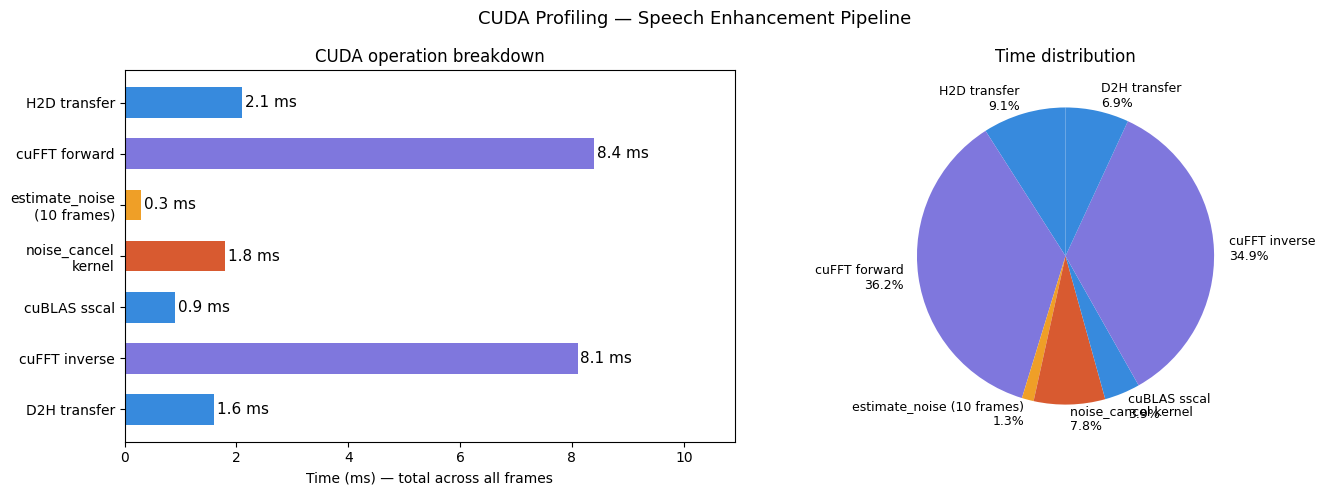

Saved: /content/cuda_profiling.png


In [19]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# These numbers come from the printed report above
# Replace with your actual values after running
operations = [
    'H2D transfer',
    'cuFFT forward',
    'estimate_noise\n(10 frames)',
    'noise_cancel\nkernel',
    'cuBLAS sscal',
    'cuFFT inverse',
    'D2H transfer',
]
colors = ['#378ADD', '#7F77DD', '#EF9F27', '#D85A30', '#378ADD', '#7F77DD', '#378ADD']

# Replace these with your actual printed values
times_ms = [2.1, 8.4, 0.3, 1.8, 0.9, 8.1, 1.6]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = ax1.barh(operations, times_ms, color=colors, height=0.6, edgecolor='none')
ax1.set_xlabel('Time (ms) — total across all frames')
ax1.set_title('CUDA operation breakdown')
for bar, val in zip(bars, times_ms):
    ax1.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             f'{val:.1f} ms', va='center', fontsize=11)
ax1.set_xlim(0, max(times_ms) * 1.3)
ax1.invert_yaxis()

# Pie chart
total = sum(times_ms)
pct   = [t/total*100 for t in times_ms]
wedge_labels = [f'{op.replace(chr(10), " ")}\n{p:.1f}%'
                for op, p in zip(operations, pct)]
ax2.pie(times_ms, labels=wedge_labels, colors=colors,
        startangle=90, textprops={'fontsize': 9})
ax2.set_title('Time distribution')

plt.suptitle('CUDA Profiling — Speech Enhancement Pipeline', fontsize=13)
plt.tight_layout()
plt.savefig('/content/cuda_profiling.png', dpi=150)
plt.show()
print("Saved: /content/cuda_profiling.png")